In [17]:
%matplotlib inline
import csv
import os
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import get_cmap
import numpy as np
import xarray as xr



In [18]:

# ── Column layout from the Nordicana D fixed-width spec ──────────────────────
#  01-05   data code
#  06-12   station code
#  13-21   latitude
#  22-30   longitude
#  31-34   year
#  35-36   month
#  37-38   day
#  39-58   substation code  (e.g. "                 T01")
#  59+     value

# Substation → depth label mapping (from the site metadata)
SUBSTATION_DEPTHS = {
    "T01": "25cm",
    "T02": "50cm",
    "T03": "75cm",
    "T04": "100cm",
    "T05": "150cm",
    "T06": "200cm",
    "T07": "300cm",
    "T08": "400cm",
    "T09": "500cm",
    "T10": "600cm",
    "T11": "700cm",
    "T12": "800cm",
    "T13": "900cm",
    "T14": "1000cm",
    "T15": "1200cm",
    "T16": "1500cm",
}

MISSING = -99999


def parse_line(line: str) -> dict | None:
    """Parse one fixed-width record. Returns None if line is too short or missing."""
    line = line.rstrip("\n")
    if len(line) < 59:
        return None

    data_code    = line[0:5].strip()
    station_code = line[5:12].strip()
    latitude     = line[12:21].strip()
    longitude    = line[21:30].strip()
    year         = int(line[30:34])
    month        = int(line[34:36])
    day          = int(line[36:38])
    substation   = line[38:58].strip()   # e.g. "T01", "T16"
    value_str    = line[58:].strip()

    try:
        value = float(value_str)
    except ValueError:
        return None

    if value == MISSING:
        value = None

    depth_label = SUBSTATION_DEPTHS.get(substation, substation)

    return {
        "date":         date(year, month, day).isoformat(),
        "station_code": station_code,
        "latitude":     latitude,
        "longitude":    longitude,
        "substation":   substation,
        "depth":        depth_label,
        "temperature_c": value,
        "data_code":    data_code,
    }


def parse_to_wide_csv(input_path: str, output_path: str) -> None:
    """
    Parse the fixed-width file and write a wide-format CSV where each column
    is a sensor depth, making it easy to plot all depths on one chart.

    Output columns:
        date, station_code, 25cm, 50cm, 75cm, ... 1500cm
    """
    # ── 1. Read all records ──────────────────────────────────────────────────
    records: dict[tuple, dict] = {}   # key = (date, station_code)

    #with open(input_path, "r", encoding="utf-16") as f:
    with open(input_path, "r", encoding="utf-16", errors="replace") as f:
        for raw in f:
            parsed = parse_line(raw)
            if parsed is None:
                continue
            key = (parsed["date"], parsed["station_code"])
            if key not in records:
                records[key] = {
                    "date":         parsed["date"],
                    "station_code": parsed["station_code"],
                    "latitude":     parsed["latitude"],
                    "longitude":    parsed["longitude"],
                }
            records[key][parsed["depth"]] = parsed["temperature_c"]

    # ── 2. Build ordered depth columns ──────────────────────────────────────
    depth_cols = list(SUBSTATION_DEPTHS.values())   # 25cm … 1500cm in order

    fieldnames = ["date", "station_code", "latitude", "longitude"] + depth_cols

    # ── 3. Write CSV (sorted by date) ────────────────────────────────────────
    rows = sorted(records.values(), key=lambda r: r["date"])

    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            # Fill missing depths with empty string
            for col in depth_cols:
                row.setdefault(col, "")
            writer.writerow(row)

    print(f"Wrote {len(rows)} rows → {output_path}")


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    INPUT_FILE  = "IQ_obs/soil_temp/ds_000633435_Jour_DLY.txt"   # ← change to your actual filename
    OUTPUT_FILE = "IQ_obs/soil_temp/borehole_temperatures.csv"

    if not os.path.exists(INPUT_FILE):
        print(f"File not found: {INPUT_FILE}")
    else:
        parse_to_wide_csv(INPUT_FILE, OUTPUT_FILE)

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("IQ_obs/soil_temp/borehole_temperatures.csv", parse_dates=["date"])

DEPTH_COLS = [
    "25cm", "50cm", "75cm", "100cm", "150cm", "200cm",
    "300cm", "400cm", "500cm", "600cm", "700cm", "800cm",
    "900cm", "1000cm", "1200cm", "1500cm",
]

depth_cols = [c for c in DEPTH_COLS if c in df.columns]

# ← add this block
depth_m = {
    "25cm": 0.25, "50cm": 0.50, "75cm": 0.75, "100cm": 1.0,
    "150cm": 1.5, "200cm": 2.0, "300cm": 3.0, "400cm": 4.0,
    "500cm": 5.0, "600cm": 6.0, "700cm": 7.0, "800cm": 8.0,
    "900cm": 9.0, "1000cm": 10.0, "1200cm": 12.0, "1500cm": 15.0,
}
# Keep only depth columns that actually exist in the file
depth_cols = [c for c in DEPTH_COLS if c in df.columns]

df = df.sort_values("date")

# ── Colour map: shallow = warm, deep = cool ──────────────────────────────────
cmap = get_cmap("viridis")
colors = [cmap(i / (len(depth_cols) - 1)) for i in range(len(depth_cols))]


Wrote 1463 rows → IQ_obs/soil_temp/borehole_temperatures.csv


C:\Users\madel\AppData\Local\Temp\ipykernel_32808\1920885622.py:154: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


Saved fig3_heatmap.png


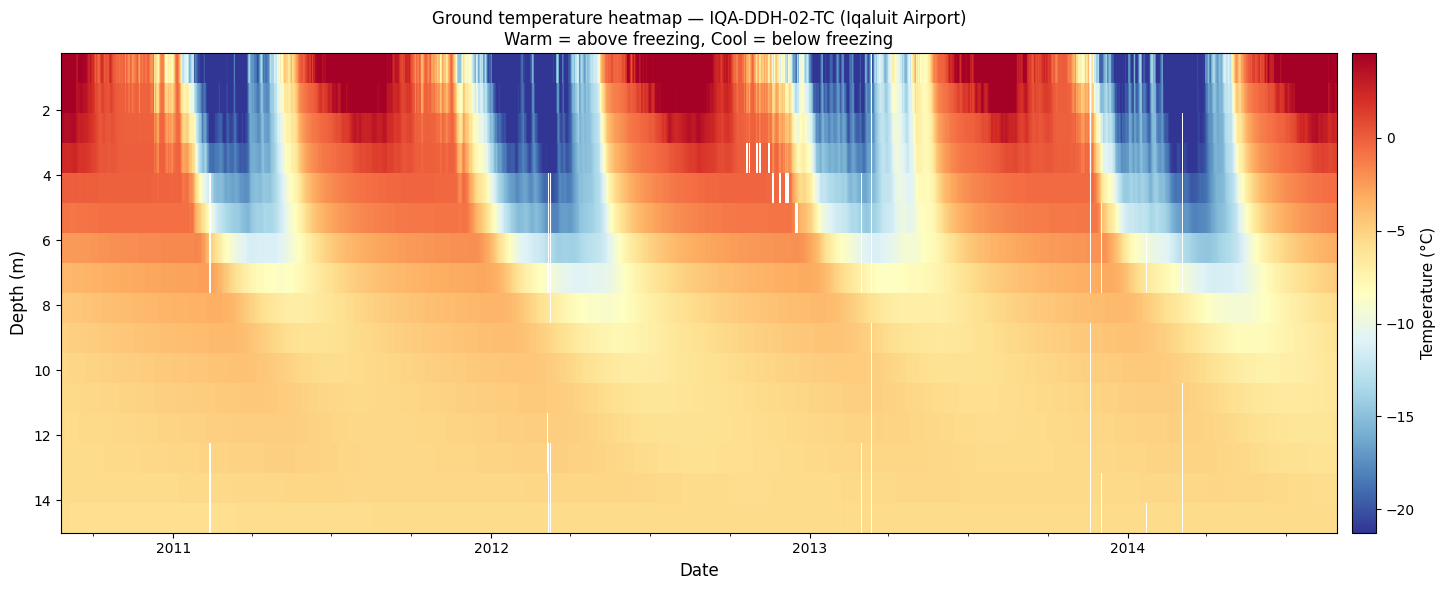

In [19]:


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Heatmap: date (x) vs depth (y), colour = temperature
#             Great for spotting seasonal cycles and long-term trends.
# ─────────────────────────────────────────────────────────────────────────────
# Build a matrix: rows = depths, columns = dates
matrix = df.set_index("date")[depth_cols].T   # shape: (n_depths, n_dates)

fig3, ax3 = plt.subplots(figsize=(16, 6))

# Convert dates to numeric for imshow x-axis
date_nums = mdates.date2num(df["date"].values)
depth_labels = [depth_m[c] for c in depth_cols]

im = ax3.imshow(
    matrix.values,
    aspect="auto",
    origin="upper",
    extent=[date_nums[0], date_nums[-1], depth_labels[-1], depth_labels[0]],
    cmap="RdYlBu_r",
    vmin=np.nanpercentile(matrix.values, 2),
    vmax=np.nanpercentile(matrix.values, 98),
    interpolation="nearest",
)

ax3.xaxis_date()
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

cbar = fig3.colorbar(im, ax=ax3, pad=0.01)
cbar.set_label("Temperature (°C)", fontsize=11)

ax3.set_xlabel("Date", fontsize=12)
ax3.set_ylabel("Depth (m)", fontsize=12)
ax3.set_title(
    "Ground temperature heatmap — IQA-DDH-02-TC (Iqaluit Airport)\n"
    "Warm = above freezing, Cool = below freezing",
    fontsize=12
)
fig3.tight_layout()
fig3.savefig("fig3_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved fig3_heatmap.png")

plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# EOF ANALYSIS — Empirical Orthogonal Functions on depth × time temperature matrix
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler

N_MODES = 4

# ── 1. Prepare the data matrix ───────────────────────────────────────────────
# matrix shape: (n_depths, n_dates)  — same as fig3
# Rows = spatial dimension (depth), Columns = time
X = matrix.values.copy()          # (n_depths, n_dates)

# Drop any columns (dates) that have all-NaN across depths
valid_cols = ~np.all(np.isnan(X), axis=0)
X = X[:, valid_cols]
dates_valid = df["date"].values[valid_cols]

# Fill remaining NaNs with row (depth-level) mean — needed for SVD
row_means = np.nanmean(X, axis=1, keepdims=True)
nan_mask  = np.isnan(X)
X_filled  = np.where(nan_mask, np.broadcast_to(row_means, X.shape), X)

# ── 2. Anomaly matrix: remove the time-mean at each depth ───────────────────
X_anom = X_filled - X_filled.mean(axis=1, keepdims=True)   # (n_depths, n_dates)

# ── 3. SVD → EOFs, PCs, variance explained ──────────────────────────────────
# Convention: SVD on the anomaly matrix
#   U  : (n_depths, n_modes)  — spatial patterns (EOFs)
#   s  : singular values
#   Vt : (n_modes, n_dates)   — temporal scores (PCs), un-scaled
U, s, Vt = np.linalg.svd(X_anom, full_matrices=False)

variance_explained = (s**2 / np.sum(s**2)) * 100   # percent

eofs = U[:, :N_MODES]            # (n_depths, N_MODES)
pcs  = np.diag(s[:N_MODES]) @ Vt[:N_MODES, :]  # (N_MODES, n_dates) — scaled scores


Saved fig4_eof_variance.png

Mode       Var. Explained   Cumulative
────────────────────────────────────────
EOF 1             91.29%       91.29%
EOF 2              7.58%       98.87%
EOF 3              0.66%       99.54%
EOF 4              0.25%       99.78%


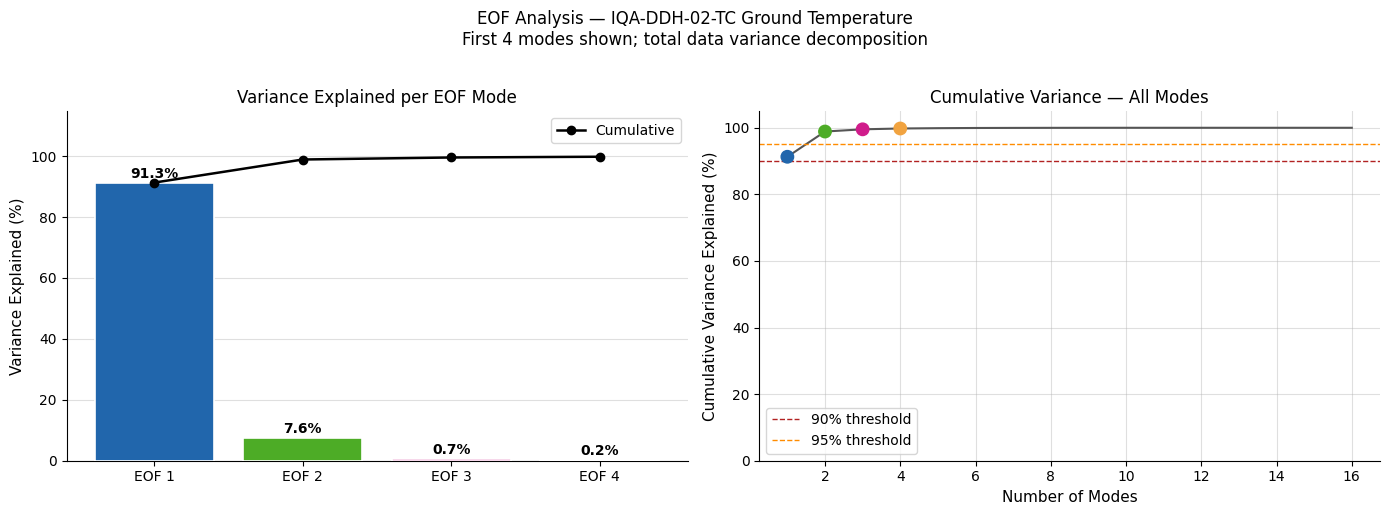

In [21]:

# ── 4. Plot: variance explained bar chart + cumulative line ─────────────────
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel — bar chart
ax_bar = axes[0]
colors = ["#2166ac", "#4dac26", "#d01c8b", "#f1a340"]
bars = ax_bar.bar(
    range(1, N_MODES + 1),
    variance_explained[:N_MODES],
    color=colors,
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
)
ax_bar.plot(
    range(1, N_MODES + 1),
    np.cumsum(variance_explained[:N_MODES]),
    marker="o", color="k", linewidth=1.8, zorder=4, label="Cumulative"
)
for bar, pct in zip(bars, variance_explained[:N_MODES]):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax_bar.set_xticks(range(1, N_MODES + 1))
ax_bar.set_xticklabels([f"EOF {i}" for i in range(1, N_MODES + 1)])
ax_bar.set_ylabel("Variance Explained (%)", fontsize=11)
ax_bar.set_title("Variance Explained per EOF Mode", fontsize=12)
ax_bar.set_ylim(0, max(np.cumsum(variance_explained[:N_MODES])) * 1.15)
ax_bar.legend(fontsize=10)
ax_bar.grid(axis="y", alpha=0.4, zorder=0)
ax_bar.spines[["top", "right"]].set_visible(False)

# Right panel — cumulative variance for all retained modes context
ax_cum = axes[1]
ax_cum.plot(
    range(1, len(variance_explained) + 1),
    np.cumsum(variance_explained),
    color="#555555", linewidth=1.5
)
ax_cum.scatter(
    range(1, N_MODES + 1),
    np.cumsum(variance_explained[:N_MODES]),
    color=colors, s=80, zorder=5
)
ax_cum.axhline(90, color="firebrick", linestyle="--", linewidth=1, label="90% threshold")
ax_cum.axhline(95, color="darkorange", linestyle="--", linewidth=1, label="95% threshold")
ax_cum.set_xlabel("Number of Modes", fontsize=11)
ax_cum.set_ylabel("Cumulative Variance Explained (%)", fontsize=11)
ax_cum.set_title("Cumulative Variance — All Modes", fontsize=12)
ax_cum.set_ylim(0, 105)
ax_cum.legend(fontsize=10)
ax_cum.grid(alpha=0.4)
ax_cum.spines[["top", "right"]].set_visible(False)

fig4.suptitle(
    "EOF Analysis — IQA-DDH-02-TC Ground Temperature\n"
    f"First {N_MODES} modes shown; total data variance decomposition",
    fontsize=12, y=1.02
)
fig4.tight_layout()
fig4.savefig("fig4_eof_variance.png", dpi=150, bbox_inches="tight")
print("Saved fig4_eof_variance.png")

# ── 5. Print summary table ───────────────────────────────────────────────────
print(f"\n{'Mode':<8} {'Var. Explained':>16} {'Cumulative':>12}")
print("─" * 40)
for i in range(N_MODES):
    print(f"EOF {i+1:<4} {variance_explained[i]:>14.2f}%  {np.cumsum(variance_explained)[i]:>10.2f}%")

plt.show()

Saved fig5_scree.png


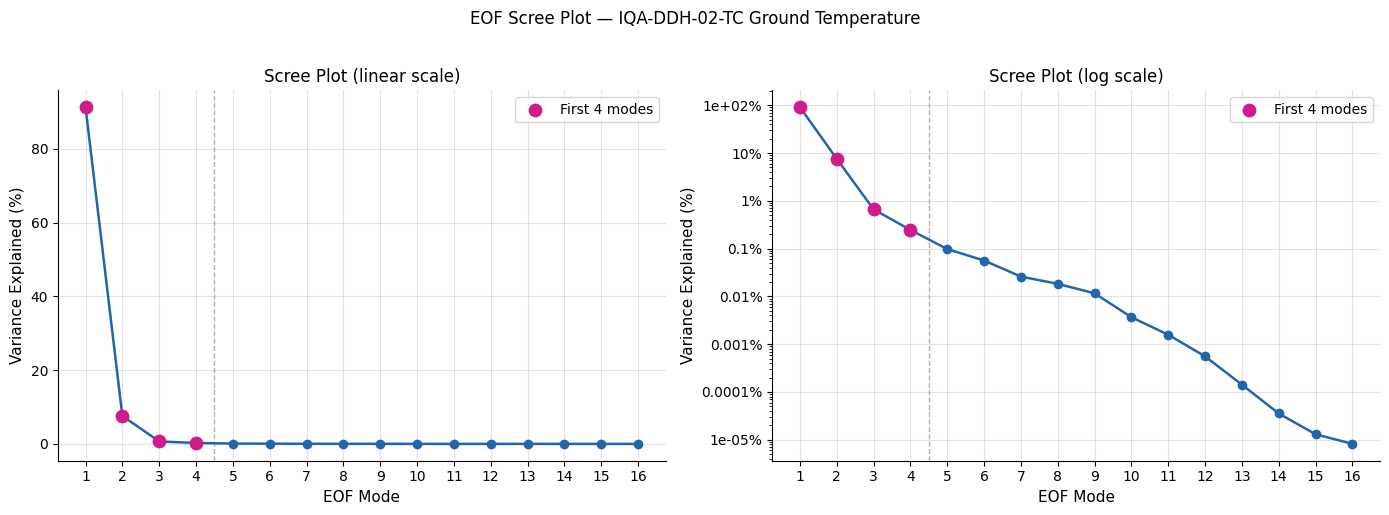

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SCREE PLOTS — linear and log-scale variance explained
# ─────────────────────────────────────────────────────────────────────────────
n_show = min(20, len(variance_explained))   # show up to 20 modes

fig5, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(14, 5))

for ax, log in [(ax_lin, False), (ax_log, True)]:
    ax.plot(
        range(1, n_show + 1),
        variance_explained[:n_show],
        marker="o", color="#2166ac", linewidth=1.8, markersize=6, zorder=4
    )
    # Highlight the first 4 modes
    ax.scatter(
        range(1, N_MODES + 1),
        variance_explained[:N_MODES],
        color="#d01c8b", s=80, zorder=5, label=f"First {N_MODES} modes"
    )
    ax.axvline(N_MODES + 0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6)

    ax.set_xlabel("EOF Mode", fontsize=11)
    ax.set_ylabel("Variance Explained (%)", fontsize=11)
    ax.set_xticks(range(1, n_show + 1))
    ax.grid(alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10)

    if log:
        ax.set_yscale("log")
        ax.set_title("Scree Plot (log scale)", fontsize=12)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda y, _: f"{y:.2g}%")
        )
    else:
        ax.set_title("Scree Plot (linear scale)", fontsize=12)
        ax.set_ylabel("Variance Explained (%)", fontsize=11)

fig5.suptitle(
    "EOF Scree Plot — IQA-DDH-02-TC Ground Temperature",
    fontsize=12, y=1.02
)
fig5.tight_layout()
fig5.savefig("fig5_scree.png", dpi=150, bbox_inches="tight")
print("Saved fig5_scree.png")
plt.show()